In [4]:
include("MiniCollectiveSpins.jl")
using PyPlot
using Statistics
using JLD2

### Define the system

In [5]:
# Nbr of particles
N_list = [2:2:10;]
r = 10
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
d0_lb = d0_lb / λ

# Quantization axis along z
e = [0, 0, 1.];

# Plots of the time evolution

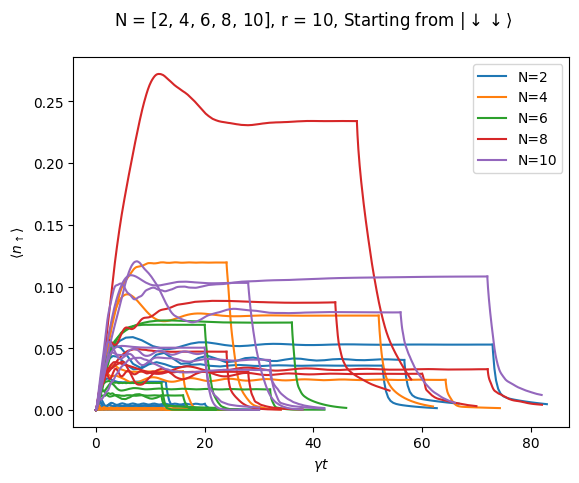

In [6]:
fig, ax = subplots()
list_t_N_SS, popup_t_N_SS, nbr_error_t_N_SS, sol_t_N_SS = [], [], [], []
list_t_N_decay, popup_t_N_decay, nbr_error_t_N_decay, sol_t_N_decay = [], [], [], []

for (i, N) in enumerate(N_list)
    line = []
    # Load SS
    @load "SS/solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t_SS, popup_t_SS, nbr_error_SS, sol_t_SS =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N_SS, list_t_SS), push!(popup_t_N_SS, popup_t_SS), push!(nbr_error_t_N_SS, nbr_error_SS), push!(sol_t_N_SS, sol_t_SS)

    # Load decay
    @load "Decay/solutions/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t_decay, popup_t_decay, nbr_error_decay, sol_t_decay =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N_decay, list_t_decay), push!(popup_t_N_decay, popup_t_decay), push!(nbr_error_t_N_decay, nbr_error_decay), push!(sol_t_N_decay, sol_t_decay)

    counter_decay = 1
    for j in 1:length(popup_t_N_SS[i])
        if j ∉ nbr_error_t_N_SS[i]
            if line == []
                line, = ax.plot(list_t_SS[j], popup_t_SS[j], label="N=$(N_list[i])") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t_SS[j], popup_t_SS[j], color=line.get_color()) # marker="o", markersize=1
            end
            ax.plot(list_t_SS[j][end] .+ list_t_decay[counter_decay], popup_t_decay[counter_decay], color=line.get_color())
            counter_decay += 1
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Plot decay rate